<a href="https://colab.research.google.com/github/mrfeagins01/Multi-Class-Prediction-of-Obesity-Risk/blob/main/DDS8555Assign7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pydataset
import pandas as pd
import matplotlib.pyplot as plt

from pydataset import data
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 36.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=7eafe2ea1388b6a85781884c7649d28b6f770e2b41f9b10534b9f91e74a126a2
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset
initiated datasets repo at: /root/.pydataset/


In [2]:
# Load USArrests data
usarrests = data("USArrests")
usarrests.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


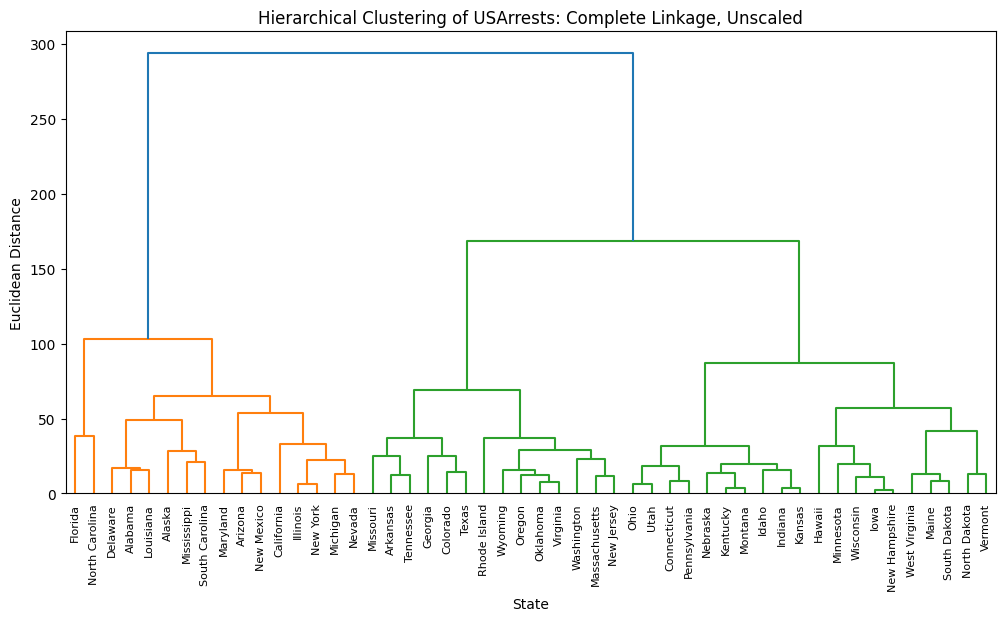

In [4]:
# Hierarchical clustering: unscaled data
Z = linkage(usarrests, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=usarrests.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of USArrests: Complete Linkage, Unscaled")
plt.xlabel("State")
plt.ylabel("Euclidean Distance")
plt.show()

In [16]:
# Cut dendrogram into 3 clusters
clusters_unscaled = fcluster(Z, t=3, criterion="maxclust")

usarrests_unscaled = usarrests.copy()
usarrests_unscaled["Cluster"] = clusters_unscaled

In [17]:
# Show states in each cluster
for cluster in sorted(usarrests_unscaled["Cluster"].unique()):
    states = usarrests_unscaled[usarrests_unscaled["Cluster"] == cluster].index.tolist()
    print(f"Cluster {cluster}: {states}")

Cluster 1: ['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']
Cluster 2: ['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']
Cluster 3: ['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']


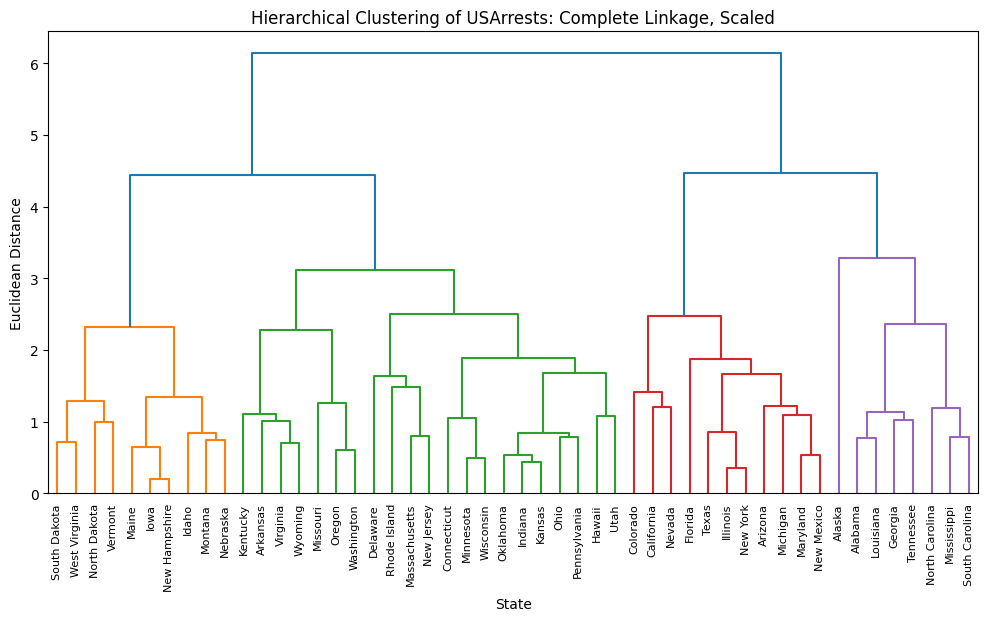

In [18]:
# Scale the variables
scaler = StandardScaler()
usarrests_scaled = scaler.fit_transform(usarrests)

Z_scaled = linkage(usarrests_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z_scaled, labels=usarrests.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of USArrests: Complete Linkage, Scaled")
plt.xlabel("State")
plt.ylabel("Euclidean Distance")
plt.show()

In [19]:
# Cut scaled dendrogram into 3 clusters
clusters_scaled = fcluster(Z_scaled, t=3, criterion="maxclust")

usarrests_scaled_results = usarrests.copy()
usarrests_scaled_results["Cluster"] = clusters_scaled

for cluster in sorted(usarrests_scaled_results["Cluster"].unique()):
    states = usarrests_scaled_results[usarrests_scaled_results["Cluster"] == cluster].index.tolist()
    print(f"Cluster {cluster}: {states}")

Cluster 1: ['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Cluster 2: ['Arizona', 'California', 'Colorado', 'Florida', 'Illinois', 'Maryland', 'Michigan', 'Nevada', 'New Mexico', 'New York', 'Texas']
Cluster 3: ['Alabama', 'Alaska', 'Georgia', 'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 'Tennessee']


In [20]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [23]:
pip install ucimlrepo

In [24]:
#Step 2: Load dataset

from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [26]:
# Step 3: Check assumptions / data quality
print(X.isnull().sum())
print(X.duplicated().sum())

# Scale data because PCA and clustering are distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
dtype: int64
0


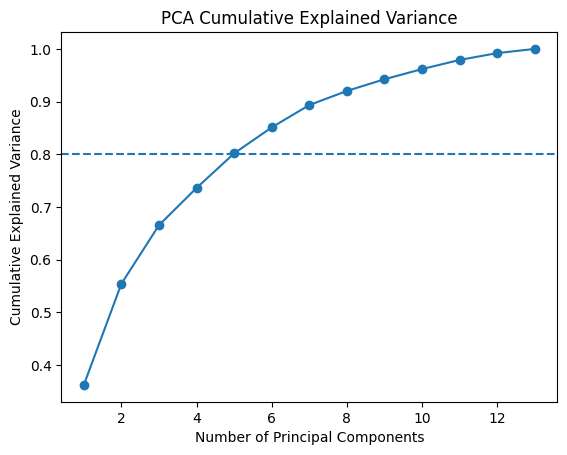

Number of components for 80% variance: 5


In [27]:
# Step 4: PCA to retain 80% variance
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()

n_components = np.argmax(explained >= 0.80) + 1
print("Number of components for 80% variance:", n_components)

pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

In [28]:
# Step 5: k-means for different k values
results = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_pca, labels)
    results.append([k, inertia, silhouette])

results_df = pd.DataFrame(results, columns=["k", "Inertia", "Silhouette"])
results_df

,k,Inertia,Silhouette
0,3,825.020838,0.369076
1,4,723.935749,0.325619
2,5,663.988882,0.264530
3,6,605.376056,0.272779
4,7,558.113912,0.275598
5,8,524.519976,0.225747


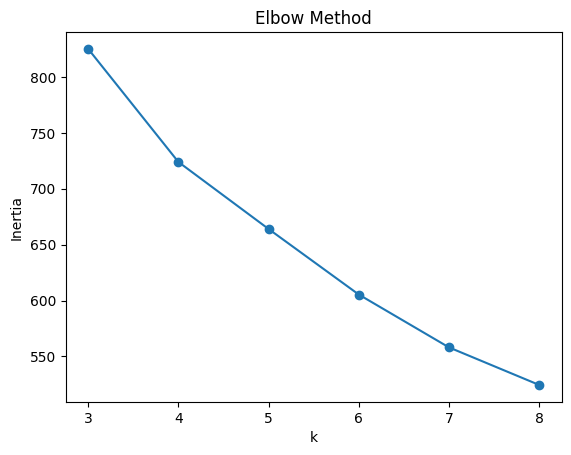

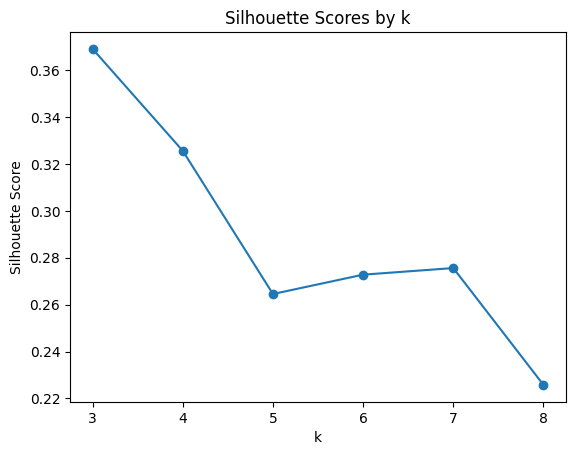

In [29]:
# Step 6: Plot k-means evaluation
plt.plot(results_df["k"], results_df["Inertia"], marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(results_df["k"], results_df["Silhouette"], marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by k")
plt.show()

In [35]:
# Step 7: Final k-means model
best_k = results_df.loc[results_df["Silhouette"].idxmax(), "k"]

final_kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
X["KMeans_Cluster"] = final_kmeans.fit_predict(X_pca)

print("Best k:", best_k)
X.groupby("KMeans_Cluster").mean()

Best k: 3


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
KMeans_Cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


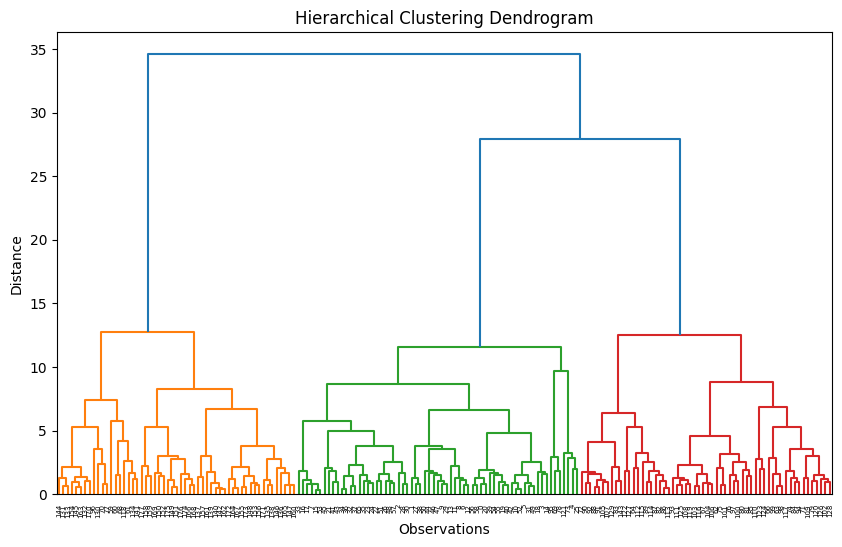

In [36]:
# Step 8: Hierarchical clustering
linked = linkage(X_pca, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In [39]:
# Step 9: Agglomerative clustering using same number of clusters
hier_model = AgglomerativeClustering(n_clusters=int(best_k), linkage="ward")
X["Hierarchical_Cluster"] = hier_model.fit_predict(X_pca)

X.groupby("Hierarchical_Cluster").mean()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,,
0,13.039091,3.081091,2.396545,20.805455,100.054545,1.694727,0.830182,0.443091,1.109455,6.842909,0.721382,1.718000,626.400000,0.890909
1,12.277414,2.054310,2.245862,20.575862,89.172414,2.286207,2.130517,0.363276,1.649138,3.017414,1.054483,2.872069,485.086207,0.034483
2,13.613385,1.957846,2.448769,17.421538,108.907692,2.811077,2.953538,0.291846,1.946308,5.368769,1.070615,3.135538,1082.461538,1.907692
